<p align="center">
  <span style="color:Navy; font-size:200%; font-weight:bold; vertical-align:middle;">
   Herramientas Computacionales Avanzadas
  </span>
  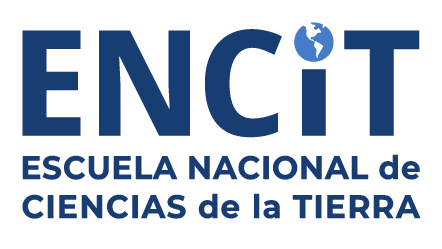
</p>
<p align="center" style="line-height:1.2;">
  <span style="color:RoyalBlue; font-size:160%;">Tema 2: Manejo de datos</span><br/>
  <span style="color:DodgerBlue; font-size:140%;">Notebook 2: Datos txt y csv </span><br/>
  <span style="font-size:100%;color:forestgreen"> Escuela Nacional de Ciencias de la Tierra  |  Semestre 2026-II</span>
</p>

---


# **<font color="ForestGreen">  Manejo de datos en formato csv </font>**

El formato _CSV_ (Comma-Separated Values) es una de las formas más comunes de almacenar y compartir datos en el análisis de datos. En un archivo _CSV_, los datos se organizan en forma de tabla, donde cada fila representa una observación o registro y cada columna representa una variable o característica. Los valores en el archivo _CSV_ están separados por comas (o a veces por otro delimitador, como un punto y coma o una tabulación). 

El estar formateados por comas hace que los archivos _CSV_ sean fáciles de leer y escribir tanto para humanos como para computadoras. Una de las principales ventajas del formato _CSV_ es su simplicidad y su compatibilidad con una amplia gama de herramientas de análisis de datos, como hojas de cálculo, bases de datos y lenguajes de programación como Python.





## **<font color="SeaGreen">  Compendio de sismos </font>**

### **<font color="Olive">  Servicio Sismológico Nacional </font>** 


En este notebook analizaremos una base de datos en formato **CSV** correspondiente a sismos registrados en México.  
Los datos fueron obtenidos del **Servicio Sismológico Nacional (SSN)** y contienen información de eventos sísmicos con **magnitud mayor o igual a 4.1**, ocurridos entre **2001 y 2024**.

El estudio de estos registros permite explorar patrones espaciales y temporales de la actividad sísmica, identificar regiones con mayor recurrencia de eventos y comprender mejor los procesos tectónicos que afectan al territorio nacional.

**Características de los datos**

- **Período:** 2001 – 2024  
- **Filtro:** magnitud ≥ 4.1  
- **Frecuencia:** registro por evento sísmico  
- **Variables principales:** fecha, hora, latitud, longitud, profundidad y magnitud  
- **Cobertura:** eventos localizados en México y regiones cercanas

Para conocer más sobre el catálogo sísmico nacional:

- http://www.ssn.unam.mx/
- http://www2.ssn.unam.mx:8080/catalogo/

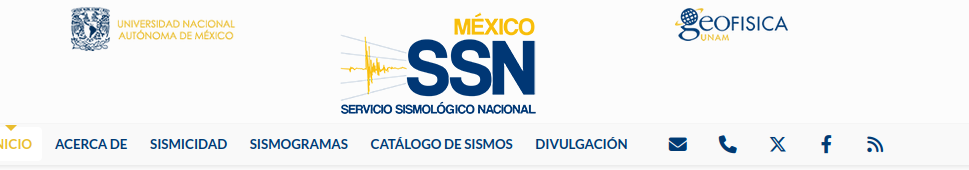

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime

def grafico_linea_ts(xmin,xmax,xlab,ylab,title,ymin=None,ymax=None,legend=False):
    # especificar limites minimos y maximos del grafico
    plt.xlim([xmin,xmax])
    plt.ylim([ymin,ymax])
    # cuadrilla interna del grafico
    plt.grid(linestyle='--',alpha=0.66)
    plt.minorticks_on()
    # hacer las etiquetas de ambos ejes mas grandes
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    # poner las labels de los ejes y el titulo
    plt.xlabel(xlab,fontsize=14)
    plt.ylabel(ylab,fontsize=14)
    plt.title(title,fontsize=15)
    # checar si queremos leyenda, si sí, la ponemos y fancy
    if legend:
        plt.legend(fontsize=12.5,fancybox=True,shadow=True)

La lectura y escritura de archivos CSV con Pandas es fundamental para importar datos desde diferentes fuentes, como hojas de cálculo, bases de datos y sistemas de almacenamiento en la nube, así como para exportar datos procesados a diferentes formatos. En esta introducción, exploraremos cómo usar Pandas para leer datos de archivos CSV en un DataFrame de Pandas y cómo escribir un DataFrame de Pandas de vuelta a un archivo CSV.

Para empezar, importaremos la biblioteca Pandas en nuestro entorno de trabajo. Luego, utilizaremos la función `pd.read_csv()` para leer un archivo CSV y cargar los datos en un DataFrame de Pandas. 
Por otro lado, exploraremos cómo usar el método `to_csv()` para escribir un DataFrame de Pandas en un archivo CSV. 

La sintaxis de `pd.read_csv()` es sencilla, siempre y cuando nuestros datos de csv estén bien formateados de origen. 

Spoiler, la Red de Monitoreo no los tiene tan bonitos como aquí. 

Para usar `pd.read_csv()` solo le damos como argumento un `str` que sea la dirección **correcta** de nuestro archivo. 


In [2]:
# carga de archivo csv
df=pd.read_csv('SSNMX_catalogo_ejemplo.csv',header=4)
df

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,2002-01-01,10:05:39,4.2,19.170,-104.790,39.0,"25 km al SUROESTE de CIHUATLAN, JAL",2002-01-01,16:05:39,revisado
1,2002-01-01,15:58:09,4.3,17.440,-95.710,111.0,"68 km al SUROESTE de ISLA, VER",2002-01-01,21:58:09,revisado
2,2002-01-01,19:28:47,4.7,18.640,-101.580,59.0,"64 km al SUR de ARIO DE ROSALES, MICH",2002-01-02,01:28:47,revisado
3,2002-01-02,13:00:51,4.3,16.180,-95.840,67.0,"55 km al NORESTE de CRUCECITA, OAX",2002-01-02,19:00:51,revisado
4,2002-01-02,20:29:18,5.3,18.940,-109.420,20.0,"440 km al SUR de CABO SAN LUCAS, BCS",2002-01-03,02:29:18,revisado
...,...,...,...,...,...,...,...,...,...,...
23111,2026-02-11,12:08:57,4.1,16.703,-99.448,11.2,"12 km al SUROESTE de SAN MARCOS, GRO",2026-02-11,18:08:57,verificado
23112,2026-02-11,15:52:50,4.1,16.939,-100.544,3.3,"32 km al SUROESTE de ATOYAC DE ALVAREZ, GRO",2026-02-11,21:52:50,verificado
23113,2026-02-11,21:45:08,4.2,27.499,-111.381,10.5,"66 km al SUROESTE de H GUAYMAS, SON",2026-02-12,03:45:08,verificado
23114,2026-02-12,00:08:09,4.1,16.624,-94.663,101.2,"24 km al NORESTE de UNION HIDALGO, OAX",2026-02-12,06:08:09,verificado


Estos datos tienen 10 columnas:

- Fecha: La fecha en formato de año, mes, día. 
- Hora: hora, minuto y segundo. 
- Magnitud: valor de concentración medido
- Latitud: latitud
- Longitud: en grados
- Referencia de localización: descripción de lugar del sismo con respecto a puntos de referencia.

### **<font color="SeaGreen"> Pequeñas transformaciones de datos </font>**

A menos que ya hayan procesado mucho sus datos, seguramente los datos "crudos" no serán directamente útiles para su análisis y querrán cambiar algunas cosas que no les gusten. 

Por ejemplo, la Red de Monitoreo le llama a su columna de estación `id_station` pero a mí no me gusta mucho. 

Para cambiarle el nombre a una columna, se utiliza el método rename, el cuál requiere un diccionario que le diga qué cambios se hacen, primero el nombre anterior y luego el nombre nuevo, y en qué eje. 

Las columnas en Pandas son el eje 1, mientras que las filas son el eje 0. 

De manera que si quisiéramos cambiarle el nombre a la columna de estación por "Estacion", se hace de la siguiente forma:

In [3]:
# renombrando los nombres de columnas
df=df.rename({'Fecha':'Dia'},axis=1)
df

,Dia,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,2002-01-01,10:05:39,4.2,19.170,-104.790,39.0,"25 km al SUROESTE de CIHUATLAN, JAL",2002-01-01,16:05:39,revisado
1,2002-01-01,15:58:09,4.3,17.440,-95.710,111.0,"68 km al SUROESTE de ISLA, VER",2002-01-01,21:58:09,revisado
2,2002-01-01,19:28:47,4.7,18.640,-101.580,59.0,"64 km al SUR de ARIO DE ROSALES, MICH",2002-01-02,01:28:47,revisado
3,2002-01-02,13:00:51,4.3,16.180,-95.840,67.0,"55 km al NORESTE de CRUCECITA, OAX",2002-01-02,19:00:51,revisado
4,2002-01-02,20:29:18,5.3,18.940,-109.420,20.0,"440 km al SUR de CABO SAN LUCAS, BCS",2002-01-03,02:29:18,revisado
...,...,...,...,...,...,...,...,...,...,...
23111,2026-02-11,12:08:57,4.1,16.703,-99.448,11.2,"12 km al SUROESTE de SAN MARCOS, GRO",2026-02-11,18:08:57,verificado
23112,2026-02-11,15:52:50,4.1,16.939,-100.544,3.3,"32 km al SUROESTE de ATOYAC DE ALVAREZ, GRO",2026-02-11,21:52:50,verificado
23113,2026-02-11,21:45:08,4.2,27.499,-111.381,10.5,"66 km al SUROESTE de H GUAYMAS, SON",2026-02-12,03:45:08,verificado
23114,2026-02-12,00:08:09,4.1,16.624,-94.663,101.2,"24 km al NORESTE de UNION HIDALGO, OAX",2026-02-12,06:08:09,verificado


También me gusta más cambiar el "Magnitud" por "Mw". 

Imprimimos de nuevo el dataframe para ver cómo cambiaron los nombres de las columnas.

In [4]:
# vamos a intentar, y fracasar en cambiar ahora la magnitud por el acronimo de magnitud utilizado
df=df.rename({'Mw':'Magnitud'},axis=1)
df

,Dia,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
0,2002-01-01,10:05:39,4.2,19.170,-104.790,39.0,"25 km al SUROESTE de CIHUATLAN, JAL",2002-01-01,16:05:39,revisado
1,2002-01-01,15:58:09,4.3,17.440,-95.710,111.0,"68 km al SUROESTE de ISLA, VER",2002-01-01,21:58:09,revisado
2,2002-01-01,19:28:47,4.7,18.640,-101.580,59.0,"64 km al SUR de ARIO DE ROSALES, MICH",2002-01-02,01:28:47,revisado
3,2002-01-02,13:00:51,4.3,16.180,-95.840,67.0,"55 km al NORESTE de CRUCECITA, OAX",2002-01-02,19:00:51,revisado
4,2002-01-02,20:29:18,5.3,18.940,-109.420,20.0,"440 km al SUR de CABO SAN LUCAS, BCS",2002-01-03,02:29:18,revisado
...,...,...,...,...,...,...,...,...,...,...
23111,2026-02-11,12:08:57,4.1,16.703,-99.448,11.2,"12 km al SUROESTE de SAN MARCOS, GRO",2026-02-11,18:08:57,verificado
23112,2026-02-11,15:52:50,4.1,16.939,-100.544,3.3,"32 km al SUROESTE de ATOYAC DE ALVAREZ, GRO",2026-02-11,21:52:50,verificado
23113,2026-02-11,21:45:08,4.2,27.499,-111.381,10.5,"66 km al SUROESTE de H GUAYMAS, SON",2026-02-12,03:45:08,verificado
23114,2026-02-12,00:08:09,4.1,16.624,-94.663,101.2,"24 km al NORESTE de UNION HIDALGO, OAX",2026-02-12,06:08:09,verificado


### **<font color="SeaGreen"> Declarando la fecha y el índice </font>**

El método `pd.to_datetime` en Pandas se utiliza para convertir objetos de fecha y hora en el formato datetime de Python. Este método es extremadamente útil cuando se trabaja con datos de series temporales, ya que permite manipular y analizar fácilmente fechas y horas en un DataFrame de Pandas.

Cuando se aplica `pd.to_datetime` a una serie o columna de un DataFrame de Pandas que contiene datos de fecha y hora en diferentes formatos (como cadenas de texto, números enteros o objetos de fecha y hora), Pandas intentará convertir estos datos en objetos datetime de Python de manera inteligente y eficiente. Esto significa que el método pd.to_datetime puede manejar una variedad de formatos de entrada, incluidas fechas y horas en formato ISO, formatos de fecha comunes, como 'YYYY-MM-DD', y formatos personalizados.



In [5]:
df['Dia']=pd.to_datetime(df.Dia)
print(df)


             Dia      Hora  Magnitud  Latitud  Longitud  Profundidad  \
0     2002-01-01  10:05:39       4.2   19.170  -104.790         39.0   
1     2002-01-01  15:58:09       4.3   17.440   -95.710        111.0   
2     2002-01-01  19:28:47       4.7   18.640  -101.580         59.0   
3     2002-01-02  13:00:51       4.3   16.180   -95.840         67.0   
4     2002-01-02  20:29:18       5.3   18.940  -109.420         20.0   
...          ...       ...       ...      ...       ...          ...   
23111 2026-02-11  12:08:57       4.1   16.703   -99.448         11.2   
23112 2026-02-11  15:52:50       4.1   16.939  -100.544          3.3   
23113 2026-02-11  21:45:08       4.2   27.499  -111.381         10.5   
23114 2026-02-12  00:08:09       4.1   16.624   -94.663        101.2   
23115 2026-02-12  12:33:32       4.6   17.636   -98.599         55.7   

                         Referencia de localizacion   Fecha UTC  Hora UTC  \
0               25 km al SUROESTE de CIHUATLAN, JAL  2002-

Ahora cambiaremos el índice y lo sustuiremos por la columna de fecha. ¿Por qué? Es útil que el índice en un DataFrame de Pandas esté en formato pd.to_datetime por varias razones:

1. Facilidad de manipulación temporal: Al tener el índice en formato datetime, Pandas proporciona una amplia gama de métodos y funciones para realizar operaciones de indexación y selección basadas en fechas y horas. Esto facilita la realización de análisis temporales, como filtrar datos por rangos de fechas, realizar agregaciones temporales y calcular diferencias temporales.

2. Interpolación y rellenado de datos faltantes: Pandas ofrece funcionalidades de interpolación y rellenado de datos faltantes que pueden ser particularmente útiles en datos de series temporales. Al tener el índice en formato datetime, Pandas puede interpolarse y rellenarse fácilmente valores faltantes basados en fechas y horas.

3. Visualización y gráficos temporales: Tener el índice en formato datetime facilita la creación de visualizaciones y gráficos temporales utilizando herramientas integradas de Pandas y bibliotecas de visualización como Matplotlib y Seaborn. Esto permite explorar y comunicar patrones temporales en los datos de manera efectiva.

In [6]:
# sustituimos el indice
df.index=df.Dia
# imprimimos las primeras columnas
print(df.head())


                  Dia      Hora  Magnitud  Latitud  Longitud  Profundidad  \
Dia                                                                         
2002-01-01 2002-01-01  10:05:39       4.2    19.17   -104.79         39.0   
2002-01-01 2002-01-01  15:58:09       4.3    17.44    -95.71        111.0   
2002-01-01 2002-01-01  19:28:47       4.7    18.64   -101.58         59.0   
2002-01-02 2002-01-02  13:00:51       4.3    16.18    -95.84         67.0   
2002-01-02 2002-01-02  20:29:18       5.3    18.94   -109.42         20.0   

                       Referencia de localizacion   Fecha UTC  Hora UTC  \
Dia                                                                       
2002-01-01    25 km al SUROESTE de CIHUATLAN, JAL  2002-01-01  16:05:39   
2002-01-01         68 km al SUROESTE de ISLA, VER  2002-01-01  21:58:09   
2002-01-01  64 km al SUR de ARIO DE ROSALES, MICH  2002-01-02  01:28:47   
2002-01-02     55 km al NORESTE de CRUCECITA, OAX  2002-01-02  19:00:51   
2002-01-02

In [7]:
# nos deshacemos de la columna Date pero no del índice
df=df.drop('Dia',axis=1)
df

,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
Dia,,,,,,,,,
2002-01-01,10:05:39,4.2,19.170,-104.790,39.0,"25 km al SUROESTE de CIHUATLAN, JAL",2002-01-01,16:05:39,revisado
2002-01-01,15:58:09,4.3,17.440,-95.710,111.0,"68 km al SUROESTE de ISLA, VER",2002-01-01,21:58:09,revisado
2002-01-01,19:28:47,4.7,18.640,-101.580,59.0,"64 km al SUR de ARIO DE ROSALES, MICH",2002-01-02,01:28:47,revisado
2002-01-02,13:00:51,4.3,16.180,-95.840,67.0,"55 km al NORESTE de CRUCECITA, OAX",2002-01-02,19:00:51,revisado
2002-01-02,20:29:18,5.3,18.940,-109.420,20.0,"440 km al SUR de CABO SAN LUCAS, BCS",2002-01-03,02:29:18,revisado
...,...,...,...,...,...,...,...,...,...
2026-02-11,12:08:57,4.1,16.703,-99.448,11.2,"12 km al SUROESTE de SAN MARCOS, GRO",2026-02-11,18:08:57,verificado
2026-02-11,15:52:50,4.1,16.939,-100.544,3.3,"32 km al SUROESTE de ATOYAC DE ALVAREZ, GRO",2026-02-11,21:52:50,verificado
2026-02-11,21:45:08,4.2,27.499,-111.381,10.5,"66 km al SUROESTE de H GUAYMAS, SON",2026-02-12,03:45:08,verificado


Ahora que el índice tiene formato de fecha, accedemos a toda una gama de atributos, funciones y posibilidades de manipular nuestros datos con fechas. 

Entre los atributos más utilizados se encuentra el uso de "month", "day" y "year de la siguiente forma:

In [8]:
print(df.index.month)
print(df.index.year)

Index([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       ...
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
      dtype='int32', name='Dia', length=23116)
Index([2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002, 2002,
       ...
       2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026],
      dtype='int32', name='Dia', length=23116)


La lista completa de atributos de un `DataFrame.DatetimeIndex` la pueden encontrar aquí:

https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.html

Podemos usar estos atributos para hacer un slice sobre el dataframe original. Es decir, vamos a recortar los datos a sólo los datos del 2023.

In [9]:
df2023=df.loc[df.index.year==2023]
df2023

,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
Dia,,,,,,,,,
2023-01-01,13:37:16,4.4,15.7090,-92.2737,211.4,"15 km al NOROESTE de FRONTERA COMALAPA, CHIS",2023-01-01,19:37:16,revisado
2023-01-01,16:46:26,4.1,14.2998,-93.8288,15.0,"162 km al SUROESTE de MAPASTEPEC, CHIS",2023-01-01,22:46:26,revisado
2023-01-02,03:57:51,4.4,16.0778,-95.5797,49.7,"43 km al SUROESTE de SALINA CRUZ, OAX",2023-01-02,09:57:51,revisado
2023-01-03,10:04:43,4.3,16.8573,-93.8257,160.1,"21 km al NOROESTE de CINTALAPA, CHIS",2023-01-03,16:04:43,revisado
2023-01-03,12:27:22,4.2,16.8180,-95.0015,108.9,"7 km al SURESTE de MATIAS ROMERO, OAX",2023-01-03,18:27:22,revisado
...,...,...,...,...,...,...,...,...,...
2023-12-29,06:45:52,4.1,16.5388,-96.3208,63.9,"37 km al NORESTE de MIAHUATLAN, OAX",2023-12-29,12:45:52,revisado
2023-12-29,10:42:56,4.5,14.4720,-92.8343,5.8,"77 km al SUROESTE de CD HIDALGO, CHIS",2023-12-29,16:42:56,revisado
2023-12-29,15:31:42,4.2,15.1643,-94.6580,17.1,"126 km al SURESTE de SALINA CRUZ, OAX",2023-12-29,21:31:42,revisado


Y ahora solamente a los datos de febrero. 
Noten bien que los meses se cuentan desde el 1 hasta el 12. El 12 es diciembre, naturalmente.

In [10]:
df_feb=df.loc[df.index.month==2]
df_feb

,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
Dia,,,,,,,,,
2002-02-01,17:58:03,4.3,15.820,-93.480,104.0,"33 km al NOROESTE de PIJIJIAPAN, CHIS",2002-02-01,23:58:03,revisado
2002-02-02,11:51:02,4.6,25.220,-108.950,10.0,"58 km al SUROESTE de ADOLFO RUIZ CORTINES, SIN",2002-02-02,17:51:02,revisado
2002-02-05,09:51:45,4.2,17.090,-99.350,11.0,"33 km al NORTE de SAN MARCOS, GRO",2002-02-05,15:51:45,revisado
2002-02-06,04:06:51,4.1,15.960,-98.370,7.0,"54 km al SUROESTE de PINOTEPA NACIONAL, OAX",2002-02-06,10:06:51,revisado
2002-02-06,17:28:03,4.4,15.010,-92.720,30.0,"31 km al SUROESTE de HUIXTLA, CHIS",2002-02-06,23:28:03,revisado
...,...,...,...,...,...,...,...,...,...
2026-02-11,12:08:57,4.1,16.703,-99.448,11.2,"12 km al SUROESTE de SAN MARCOS, GRO",2026-02-11,18:08:57,verificado
2026-02-11,15:52:50,4.1,16.939,-100.544,3.3,"32 km al SUROESTE de ATOYAC DE ALVAREZ, GRO",2026-02-11,21:52:50,verificado
2026-02-11,21:45:08,4.2,27.499,-111.381,10.5,"66 km al SUROESTE de H GUAYMAS, SON",2026-02-12,03:45:08,verificado


Otros métodos de Pandas útiles para operar rápidamente nuestra base de datos. 

- `unique()`: Este método se utiliza para obtener los valores únicos en una serie. Es especialmente útil cuando se quiere identificar los distintos valores presentes en una columna de un DataFrame.

- `value_counts()`: Este método cuenta la frecuencia de cada valor único en una serie. Es útil para determinar la distribución de los valores en una columna.

Por ejemplo, si queremos ver cuáles son las mediciones únicas de magnitud en nuestra base de datos podemos hacer lo siguiente:

In [11]:
magnitudes=df['Magnitud'].unique()
print(magnitudes)

[4.2 4.3 4.7 5.3 4.1 4.5 4.4 6.7 4.9 4.6 5.6 5.  4.8 5.8 5.5 5.1 5.4 6.5
 6.  5.2 6.2 6.8 7.6 5.9 6.3 5.7 6.4 6.6 7.2 6.1 7.5 7.3 6.9 8.2 7.1 7.4
 7.7]


In [12]:
# slice para agarrar magnitudes mayores a 6
print(df[df['Magnitud']>6.0])

                Hora  Magnitud  Latitud  Longitud  Profundidad  \
Dia                                                              
2002-01-16  17:09:55       6.7  15.4300  -93.5500         76.0   
2002-04-18  00:02:45       6.5  16.7700 -101.1200         22.0   
2002-10-03  11:08:28       6.2  23.2200 -108.7300         35.0   
2003-01-20  20:46:54       6.8  13.3600  -91.6400         17.0   
2003-01-21  20:06:34       7.6  18.6000 -104.2200          9.0   
...              ...       ...      ...       ...          ...   
2023-06-18  14:30:22       6.4  23.2087 -108.5120          5.0   
2023-07-14  03:29:01       6.5  14.8393  -94.1367         16.1   
2024-05-12  05:39:12       6.3  14.3118  -92.6370         11.3   
2025-01-12  02:32:53       6.1  18.4960 -103.4990         30.0   
2026-01-02  07:58:15       6.5  16.7700  -99.4130          5.0   

                          Referencia de localizacion   Fecha UTC  Hora UTC  \
Dia                                                            

In [13]:
# cuantas veces contamos magnitudes de 5 o mas
cuentas=df[df['Magnitud']>8].value_counts()
print(cuentas.values)

[1]


**Más slicing**

Como ya hemos aludido en celdas pasadas al concepto de slicing, veremos un poco más de cómo recortar nuesto dataframe. La sintaxis básica de slicing en Pandas es con `df.loc[condition]` que se utiliza para seleccionar un subconjunto de filas de un DataFrame que cumplan con cierta condición. 

Aquí otro ejemplo para seleccionar una estación específica de todas las estaciones de monitoreo y sólo quedarnos con los datos de esa estación. 

Específicamenete, usaremos la estación del CCA que es la que se encuentra a escasos 100 m de la posición del salón en lo que ahora es el _Instituto de Ciencias de la Atmósfera y Cambio Climático_. 

In [14]:
profundos=df[df.Profundidad>100]
profundos

,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
Dia,,,,,,,,,
2002-01-01,15:58:09,4.3,17.440,-95.710,111.0,"68 km al SUROESTE de ISLA, VER",2002-01-01,21:58:09,revisado
2002-01-03,08:10:30,4.5,17.560,-94.730,160.0,"43 km al SURESTE de SAYULA DE ALEMAN, VER",2002-01-03,14:10:30,revisado
2002-01-08,22:12:04,4.2,14.660,-91.770,176.0,"41 km al ESTE de CD HIDALGO, CHIS",2002-01-09,04:12:04,revisado
2002-01-12,03:01:23,4.2,16.680,-94.590,120.0,"34 km al NORESTE de UNION HIDALGO, OAX",2002-01-12,09:01:23,revisado
2002-01-21,11:36:06,4.3,17.050,-94.980,129.0,"21 km al NORESTE de MATIAS ROMERO, OAX",2002-01-21,17:36:06,revisado
...,...,...,...,...,...,...,...,...,...
2026-02-05,05:18:53,4.1,15.090,-92.198,170.7,"12 km al NOROESTE de CACAHOATAN, CHIS",2026-02-05,11:18:53,verificado
2026-02-06,03:24:02,4.3,16.552,-94.496,105.1,"37 km al ESTE de UNION HIDALGO, OAX",2026-02-06,09:24:02,verificado
2026-02-07,22:21:28,4.2,17.265,-94.868,130.3,"47 km al NORESTE de MATIAS ROMERO, OAX",2026-02-08,04:21:28,verificado


### **<font color="SeaGreen"> Pequeñas/grandes transformaciones de datos </font>**

Ahora que sabemos lo básico de Pandas podemos pasar a transformaciones un poco más complicadas. 

La clase pasada vimos lo que hace el método de `groupby` y `mean`.

Por ejemplo, una pregunta que nos podría surgir es. 

**¿Cuál es el promedio de magnitud de sismos por año?**

¿Qué año creen que haya tenido los sismos, promedio, más fuertes?





In [15]:
# agrupamos, y promediamos
print(df.groupby(df.index.year).mean(numeric_only=True))

      Magnitud    Latitud    Longitud  Profundidad
Dia                                               
2002  4.389610  16.637857  -97.979399    35.282468
2003  4.377181  16.245705  -96.780201    42.899329
2004  4.391248  16.604231  -97.442624    38.661080
2005  4.357426  16.624975  -97.346460    47.643564
2006  4.367749  16.301833  -96.909536    46.575406
2007  4.392982  16.527719  -97.129442    43.347687
2008  4.322615  15.985389  -95.862032    42.759717
2009  4.381010  17.708101  -98.460168    47.432692
2010  4.307895  19.820592 -100.886250    37.812500
2011  4.315430  18.682598  -99.009434    45.503906
2012  4.370656  17.357145  -98.132234    30.647541
2013  4.301213  17.839324  -97.848643    41.457539
2014  4.358467  17.492166  -98.370189    37.554189
2015  4.257115  17.022315  -97.242963    49.976383
2016  4.283455  17.599381  -98.764399    42.079562
2017  4.272930  16.076110  -95.852676    37.384952
2018  4.255576  16.805396  -97.040132    38.135455
2019  4.239894  16.878260  -97.

In [16]:
# pero si le sacamos el operador mean
print(df.groupby(df.index.year).max(numeric_only=True))

      Magnitud  Latitud  Longitud  Profundidad
Dia                                           
2002       6.7  32.3700  -88.0800        214.0
2003       7.6  32.1700  -89.8700        284.0
2004       6.4  32.3300  -89.1990        238.0
2005       5.9  31.9400  -87.8700        238.0
2006       6.6  28.3800  -87.2600        235.0
2007       6.3  26.4500  -90.4400        281.0
2008       6.6  32.1400  -89.4600        272.0
2009       6.5  32.7700  -86.2500        262.0
2010       7.2  32.9300  -89.0900        256.0
2011       6.7  33.0000  -86.1800        338.0
2012       7.5  33.2658  -85.5467        256.7
2013       6.3  32.5978  -86.0355        231.6
2014       7.2  32.5242  -88.1893        250.5
2015       6.6  32.4917  -87.5048        244.9
2016       6.6  32.4145  -90.7760        279.6
2017       8.2  32.5135  -91.0273        237.6
2018       7.2  32.6358  -90.8213        221.2
2019       6.5  32.3253  -91.1268        249.3
2020       7.4  32.5110  -91.3730        229.9
2021       7.

In [17]:
max_anuales = df.groupby(df.index.year).max(numeric_only=True)

Ahora que tenemos una nueva base de datos, filtrada para la estación del CCA, podemos hacer algo que tendremos que hacer muchas veces, que es guardar nuestros datos en otro archivo. Para esto se utiliza el método de `to_csv` que guarda un dataframe en un archivo. 

El nombre del archivo es el argumento de la función, así que mucho ojo con donde queremos guardar los archivos. 

In [18]:
max_anuales.to_csv('max_anuales.csv')

---
<a name='ej-1'></a>
### **<font color="DodgerBlue"> Ejercicio 1 - Septiemble </font>**


<font color="DarkBlue"> 1. Utilizando los datos de sismos, cuente cuántos sismos de magnitud superior a 5.5 han ocurrido en cada mes calendario en el periodo de estos registros. 
    
<font color="DarkBlue"> 2. Grafique sus resultados en una gráfica donde el eje x sea el 'Mes' y el eje Y '# de sismos'. ¿Tiembla más en septiembre?
    
   
    
---

# <font color="ForestGreen">Manejo de datos en formato TXT</font>

Un archivo TXT es texto plano guardado línea por línea. Cada línea suele representar un registro y los campos pueden separarse por tabulaciones, espacios, comas o punto y coma. Es común en ciencias ambientales para bitácoras, salidas de instrumentos y series temporales por su portabilidad y lectura sencilla.

Puntos clave:
- Delimitador: aclara si usas tab (`\t`), espacios, coma o punto y coma.
- Encabezados y comentarios: a veces hay una fila con nombres de columnas o líneas que empiezan con `#` con metadatos.
- Codificación: preferir UTF-8 para acentos; indícala si no es la predeterminada.
- Valores faltantes: define cómo se representan (NA, -9999, vacío).

Lectura en Python:
- `pandas.read_csv` funciona para TXT si especificas el separador (`sep="\t"` para TSV, `delim_whitespace=True` para espacios) y `comment="#"` para ignorar comentarios. Para columnas de ancho fijo, `read_fwf`.

# <font color="ForestGreen">Introducción rápida al ONI (Oceanic Niño Index)</font>

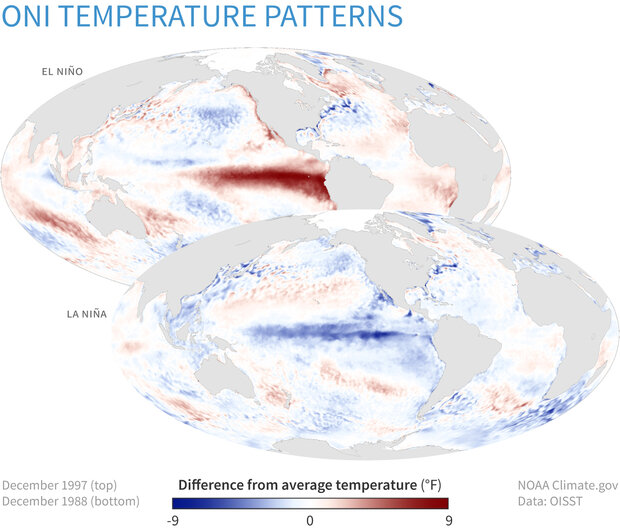

El **ONI** es un índice que resume el estado de **ENSO** (El Niño–La Niña) a partir de las **anomalías de temperatura superficial del mar** en la región **Niño 3.4** (5°N–5°S, 170°W–120°W). Se calcula como un **promedio móvil de 3 meses** (DJF, JFM, FMA, …) usando una climatología de ~30 años y datos de TSM reconstruidos (ERSST). Se actualiza mensualmente.

**¿Para qué sirve?**  
Es la referencia operativa más común para clasificar episodios:
- **El Niño**: ONI ≥ +0.5 °C durante **5** temporadas trimestres superpuestas.
- **La Niña**: ONI ≤ −0.5 °C durante **5** temporadas.
- **Neutral**: valores entre esos umbrales.

**Formato típico (TXT/ASCII)**  
Tabla por **año** con 12 columnas de temporadas solapadas (DJF, JFM, …, NDJ) y valores en °C con signo. Es texto plano, fácil de leer con `pandas.read_csv(..., delim_whitespace=True)` y útil para ejercicios de:
- filtrado por año/temporada,
- conteo de meses/temporadas El Niño vs. La Niña,
- gráficos de líneas o barras por temporada.

**Notas prácticas**  
- Las temporadas están **solapadas** (no tratarlas como meses independientes).  
- La climatología se **actualiza** cada cierto tiempo; si comparas con otras fuentes, verifica el periodo base.


In [19]:
oni=pd.read_csv('oni.ascii.txt')

In [20]:
oni

,SEAS YR TOTAL ANOM
0,DJF 1950 24.72 -1.53
1,JFM 1950 25.17 -1.34
2,FMA 1950 25.75 -1.16
3,MAM 1950 26.12 -1.18
4,AMJ 1950 26.32 -1.07
...,...
902,FMA 2025 27.11 -0.18
903,MAM 2025 27.60 -0.09
904,AMJ 2025 27.72 -0.11
905,MJJ 2025 27.54 -0.11


In [21]:
# necesitamos decir cómo se delimitan las columnas
oni=pd.read_csv('oni.ascii.txt',delim_whitespace=True)

/tmp/ipykernel_6196/2549875294.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  oni=pd.read_csv('oni.ascii.txt',delim_whitespace=True)


Text(0, 0.5, 'Indice')

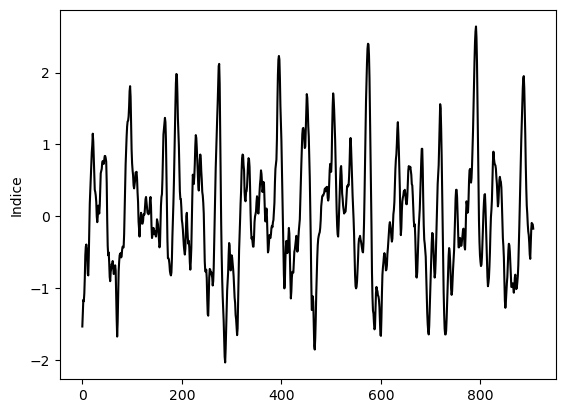

In [22]:
plt.plot(oni.ANOM,c='k')
plt.ylabel('Indice')

In [23]:
# Map seasons to their middle month
season_to_month = {'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4,'AMJ': 5, 'MJJ': 6, 'JJA': 7, 'JAS': 8,
    'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12}

## La función `map()` en Pandas

La función `map()` se aplica sobre una **Serie** de pandas y permite transformar cada valor usando un diccionario, otra Serie, o una función.

### Sintaxis básica
```python
serie.map(diccionario)
serie.map(función)
```

Cada valor de la Serie se usa como **llave** para buscar su correspondiente valor en el diccionario:
```python
season_to_month = {
    'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4,
    'AMJ': 5, 'MJJ': 6, 'JJA': 7, 'JAS': 8,
    'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12
}

oni['SEAS'].map(season_to_month)
```

| SEAS | → | mes |
|------|---|-----|
| DJF  | → | 1   |
| JFM  | → | 2   |
| FMA  | → | 3   |

> Si un valor **no existe** en el diccionario, `map()` devuelve `NaN`.


### ¿Cuándo usar `map()` vs `apply()`?

| `map()`  | `apply()` |
|----------|-----------|
| Solo sobre **Series** | Sobre Series o DataFrames |
| Ideal para **reemplazar valores** | Ideal para lógica más compleja |
| Acepta dict, Serie o función | Solo acepta funciones |

In [24]:
oni['SEAS'].map(season_to_month)

0      1
1      2
2      3
3      4
4      5
      ..
902    3
903    4
904    5
905    6
906    7
Name: SEAS, Length: 907, dtype: int64

In [25]:
oni['fecha'] = pd.to_datetime({'year': oni['YR'],
    'month': oni['SEAS'].map(season_to_month),
    'day': 1})

In [26]:
oni.index=oni['fecha']

In [27]:
oni

,SEAS,YR,TOTAL,ANOM,fecha
fecha,,,,,
1950-01-01,DJF,1950,24.72,-1.53,1950-01-01
1950-02-01,JFM,1950,25.17,-1.34,1950-02-01
1950-03-01,FMA,1950,25.75,-1.16,1950-03-01
1950-04-01,MAM,1950,26.12,-1.18,1950-04-01
1950-05-01,AMJ,1950,26.32,-1.07,1950-05-01
...,...,...,...,...,...
2025-03-01,FMA,2025,27.11,-0.18,2025-03-01
2025-04-01,MAM,2025,27.60,-0.09,2025-04-01
2025-05-01,AMJ,2025,27.72,-0.11,2025-05-01


### Separadores más comunes

Para guardar los datos, no siempre es necesario separar las columnas de nuestros datos tabulares con ',' sino que también podría ser útil otros caracteres como los espacios y los tabuladores.

| Separador | Código | Extensión típica |
|-----------|--------|-----------------|
| Coma      | `','`  | `.csv`          |
| Tabulador | `'\t'` | `.tsv` o `.txt` |
| Punto y coma | `';'` | `.csv` (Europa)|
| Espacio   | `' '`  | `.txt`          |
| Pipe      | `'|'`  | `.txt`          |

In [28]:
oni.to_csv('oni_good.txt',sep='\t')

NameError: name 'x_scatter' is not defined

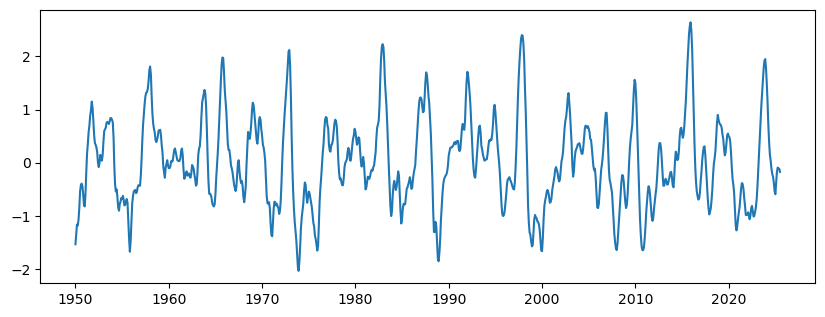

In [29]:
plt.figure(figsize=(10,3.55))
plt.plot(oni.fecha,oni.ANOM)
plt.scatter(x_scatter,y_scatter,c='tab:red')
plt.axhline(0, linewidth=1)
plt.xlabel("Fecha (temporadas ONI)")
plt.ylabel("ONI (°C)")
plt.title("Índice ONI y temporadas ≥ 0.5")
plt.tight_layout()

In [ ]:
nino=oni[oni.ANOM>0.5]
nino.to_csv('datos_nino.csv')

---
<a name='ej-1'></a>
### **<font color="OrangeRed">Ejemplo </font>**

<font color="DarkRed"> Vamos a hacer un análisis muy específico con los datos que tenemos. Específicamente, vamos a utilizar nuestros datos del indice ONI:
    
<font color="DarkRed"> 1. Obtener el promedio por mes del indice ONI en todas las estaciones. 
    
<font color="DarkRed"> 2. Graficar los resultados.
    
</font>

---
    
Para empezar el análisis, tenemos que pensar en qué queremos hacer. 
    
Metodología:
    
1. Promedios por mes. Algo con groupby y una operación de .mean(). Guardar los resultados una variable.
    
2. Graficar los resultados 

3. Mostrar en las etiquetas quiénes son los meses. 

In [ ]:
oni.fecha.dt.month

In [ ]:
mensual=oni.groupby(oni.fecha.dt.month).mean(numeric_only=True)
print(mensual)

In [ ]:
plt.plot(mensual['ANOM'])

In [ ]:
# grafica chida
plt.figure(figsize=(5,3.33),dpi=150)
plt.plot(mensual['ANOM'],c='k',linewidth=2.3)
grafico_linea_ts(0.5,12.5,'Mes','ONI [deg C]','Ciclo estacional')
meses=['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
plt.xticks(np.arange(1,13),meses,fontsize=12,rotation=15)

In [ ]:
mensual=oni.groupby(oni.fecha.dt.month).std(numeric_only=True)
# grafica chida
plt.figure(figsize=(5,3.33),dpi=150)
plt.plot(mensual['ANOM'],c='k',linewidth=2.3)
grafico_linea_ts(0.5,12.5,'Mes',r'ONI [$\sigma$ deg C]','Ciclo estacional')
meses=['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
plt.xticks(np.arange(1,13),meses,fontsize=12,rotation=15)

### Más operaciones con el tiempo

Una operación fundamental con pandas una vez que el índice es del tipo DatetimeIndex es cambiar la resolución temporal de los datos. Por ejemplo, esta base de datos tiene una resolución temporal de 1 hora pero quizás sea útil pasarlos a datos diarios. 

Para esto, se utiliza el método `resample()` y el operador `mean()`. Resample cambia la resolución o el "sampleado" de los datos. Como argumento, toma la nueva resolución donde la letra D significa días y el valor de 1 quiere decir que la nueva resolución es de 1 día. 




In [ ]:
oni.resample('1YE').mean(numeric_only=True)

¿Cómo creen que se vería la línea anterior si quisiéramos hacer un cambio en los datos pero para un promedio de 5 días?

In [ ]:
oni.resample('3M').mean(numeric_only=True)

---
<a name='ej-1'></a>
### **<font color="DodgerBlue"> Ejercicio 2 - El Niño </font>**

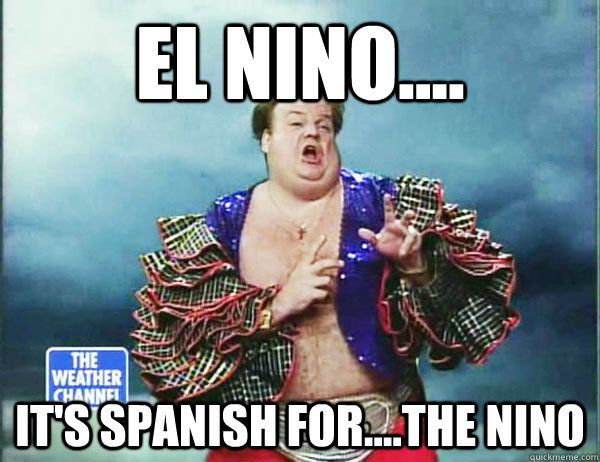

<font color="DarkBlue"> 1. Haga una serie de tiempo que se vea bonita para el indice de ONI entre 2001 y 2024.
    
<font color="DarkBlue"> 2. Repita la gráfica anterior del inciso 1 pero utilizando una frecuencia anual, a través de una operación del tipo groupby.
    
 <font color="DarkBlue"> 3. Utilizando    
    
    
---